In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [177]:
df = pd.read_csv('netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [178]:
df.shape

(8807, 12)

In [179]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [180]:
df.rename(columns = {'listed_in':'genre'},inplace = True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [181]:
df.drop(columns = 'show_id',inplace = True)

In [182]:
df.duplicated().sum()

0

In [183]:
df.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
genre              0
description        0
dtype: int64

In [184]:
df.dropna(subset = ['date_added'],inplace = True)
df['date_added'].isna().sum()

0

In [185]:
df.dropna(subset = ['rating'],inplace = True)
df['rating'].isna().sum()

0

In [186]:
df.dropna(subset = ['duration'],inplace = True)
df['duration'].isna().sum()

0

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      6169 non-null   object
 3   cast          7965 non-null   object
 4   country       7961 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   genre         8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


In [188]:
df.isna().sum()

type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
dtype: int64

In [189]:
df['date_added'] = pd.to_datetime(df['date_added'],errors = 'coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8790 non-null   object        
 1   title         8790 non-null   object        
 2   director      6169 non-null   object        
 3   cast          7965 non-null   object        
 4   country       7961 non-null   object        
 5   date_added    8702 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   genre         8790 non-null   object        
 10  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 824.1+ KB


In [190]:
df['day'] = df['date_added'].dt.day
df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year
df['month_name'] = df['date_added'].dt.month_name()
df['weekdays'] = df['date_added'].dt.day_name()

In [191]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekdays
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24.0,9.0,2021.0,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24.0,9.0,2021.0,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24.0,9.0,2021.0,September,Friday


In [192]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [193]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.NaN)

In [194]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekdays
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24.0,9.0,2021.0,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24.0,9.0,2021.0,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24.0,9.0,2021.0,September,Friday


In [195]:
df['rating'].unique()

array(['Teens', 'Adults', 'PG', 'Kids', nan], dtype=object)

In [196]:
df['rating']

0        Teens
1       Adults
2       Adults
3       Adults
4       Adults
         ...  
8802    Adults
8803      Kids
8804    Adults
8805        PG
8806     Teens
Name: rating, Length: 8790, dtype: object

In [197]:
df['rating'].isna().sum()

82

In [198]:
df.dropna(subset = ['rating'],inplace = True)
df['rating'].isna().sum()

0

In [199]:
df[(df['director'].isna()) & (df['country'].isna()) & (df['cast'].isna())].shape[0]

96

In [200]:
df.shape

(8708, 16)

In [201]:
df.dropna(subset = ['director','country','cast'],how = 'all',inplace = True)
df.shape

(8612, 16)

In [202]:
df['cast']

0                                                     NaN
1       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
4       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5       Kate Siegel, Zach Gilford, Hamish Linklater, H...
                              ...                        
8801    Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...
8802    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
8804    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
8805    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
8806    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8612, dtype: object

In [203]:
df_cast = pd.DataFrame(df['cast'].apply(lambda x: str(x).split(', ')).tolist(),index = df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [204]:
df_cast = df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 64251, dtype: object

In [205]:
df_cast = pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[64251 rows x 1 columns]

In [206]:
df_cast.reset_index(inplace = True)
df_cast = df_cast[['title',0]]
df_cast.columns = ['title','cast']
df_cast.replace('nan',np.nan,inplace = True)
df_cast.isna().sum()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\1841764931.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan',np.nan,inplace = True)


title      0
cast     712
dtype: int64

In [207]:
df_cast

,title,cast
0,Dick Johnson Is Dead,NaN
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
64246,Zubaan,Manish Chaudhary
64247,Zubaan,Meghna Malik
64248,Zubaan,Malkeet Rauni
64249,Zubaan,Anita Shabdish


In [208]:
df_genre = pd.DataFrame(df['genre'].apply(lambda x: str(x).split(', ')).tolist(),index = df['title'])
df_genre

,0,1,2
title,,,
Dick Johnson Is Dead,Documentaries,None,None
Blood & Water,International TV Shows,TV Dramas,TV Mysteries
Ganglands,Crime TV Shows,International TV Shows,TV Action & Adventure
Kota Factory,International TV Shows,Romantic TV Shows,TV Comedies
Midnight Mass,TV Dramas,TV Horror,TV Mysteries
...,...,...,...
Zinzana,Dramas,International Movies,Thrillers
Zodiac,Cult Movies,Dramas,Thrillers
Zombieland,Comedies,Horror Movies,None


In [209]:
df_genre = df_genre.stack()
df_genre

title                  
Dick Johnson Is Dead  0               Documentaries
Blood & Water         0      International TV Shows
                      1                   TV Dramas
                      2                TV Mysteries
Ganglands             0              Crime TV Shows
                                     ...           
Zoom                  0    Children & Family Movies
                      1                    Comedies
Zubaan                0                      Dramas
                      1        International Movies
                      2            Music & Musicals
Length: 18937, dtype: object

In [210]:
df_genre = pd.DataFrame(df_genre)
df_genre

0
title                                           
Dick Johnson Is Dead 0             Documentaries
Blood & Water        0    International TV Shows
                     1                 TV Dramas
                     2              TV Mysteries
Ganglands            0            Crime TV Shows
...                                          ...
Zoom                 0  Children & Family Movies
                     1                  Comedies
Zubaan               0                    Dramas
                     1      International Movies
                     2          Music & Musicals

[18937 rows x 1 columns]

In [211]:
df_genre.reset_index(inplace = True)
df_genre = df_genre[['title',0]]
df_genre.columns = ['title','genre']
df_genre.replace('nan',np.NaN,inplace = True)
df_genre.isna().sum()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\925273411.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_genre.replace('nan',np.NaN,inplace = True)


title    0
genre    0
dtype: int64

In [212]:
df_genre

,title,genre
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows
...,...,...
18932,Zoom,Children & Family Movies
18933,Zoom,Comedies
18934,Zubaan,Dramas
18935,Zubaan,International Movies


In [213]:
df_director = pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(),index = df['title'])
df_director = df_director.stack()
df_director = pd.DataFrame(df_director)
df_director.reset_index(inplace = True)
df_director = df_director[['title',0]]
df_director.columns = ['title','director']
df_director.replace('nan',np.NaN,inplace = True)
df_director.isna().sum()

title          0
director    2521
dtype: int64

In [214]:
df_director

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,NaN
2,Ganglands,Julien Leclercq
3,Kota Factory,NaN
4,Midnight Mass,Mike Flanagan
...,...,...
9403,Zinzana,Majid Al Ansari
9404,Zodiac,David Fincher
9405,Zombieland,Ruben Fleischer
9406,Zoom,Peter Hewitt


In [215]:
df_country = pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(),index = df['title'])
df_country = df_country.stack()
df_country = pd.DataFrame(df_country)
df_country.reset_index(inplace = True)
df_country = df_country[['title',0]]
df_country.columns = ['title','country']
df_country.replace('nan',np.NaN,inplace = True)
df_country.isna().sum()

title        0
country    733
dtype: int64

In [216]:
df_country

,title,country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,NaN
3,Kota Factory,India
4,Midnight Mass,NaN
...,...,...
10614,Zinzana,Jordan
10615,Zodiac,United States
10616,Zombieland,United States
10617,Zoom,United States


In [217]:
df12 = df_cast.merge(df_genre, on = 'title')
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
147927,Zubaan,Anita Shabdish,International Movies
147928,Zubaan,Anita Shabdish,Music & Musicals
147929,Zubaan,Chittaranjan Tripathy,Dramas
147930,Zubaan,Chittaranjan Tripathy,International Movies


In [218]:
df123 = df_director.merge(df12, on = 'title')
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
159583,Zubaan,Mozez Singh,Anita Shabdish,International Movies
159584,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
159585,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
159586,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [219]:
df1234 = df_country.merge(df123, on = 'title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
199945,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
199946,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
199947,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
199948,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [220]:
df_new = df.merge(df1234, on = 'title')
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekdays,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199945,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2.0,3.0,2019.0,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
199946,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2.0,3.0,2019.0,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
199947,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2.0,3.0,2019.0,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
199948,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2.0,3.0,2019.0,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [221]:
df_new.drop(columns = ['cast_x','country_x','director_x','genre_x'],inplace = True)
df_new.rename(columns = {'country_y':'country','director_y':'director','cast_y':'cast','genre_y':'genre'},inplace = True)
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [222]:
df_new.isna().sum()

type                0
title               0
date_added       1546
release_year        0
rating              0
duration            0
description         0
day              1546
month            1546
year             1546
month_name       1546
weekdays         1546
country         11710
director        50116
cast             1894
genre               0
dtype: int64

In [223]:
df_new['cast'] = df_new['cast'].replace(np.NaN,'Unknown')
df_new['country'] = df_new['country'].replace(np.NaN,'Unknown')
df_new['director'] = df_new['director'].replace(np.NaN,'Unknown')

In [224]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows


In [225]:
df_new.isna().sum()

type               0
title              0
date_added      1546
release_year       0
rating             0
duration           0
description        0
day             1546
month           1546
year            1546
month_name      1546
weekdays        1546
country            0
director           0
cast               0
genre              0
dtype: int64

In [226]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199950 entries, 0 to 199949
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   type          199950 non-null  object        
 1   title         199950 non-null  object        
 2   date_added    198404 non-null  datetime64[ns]
 3   release_year  199950 non-null  int64         
 4   rating        199950 non-null  object        
 5   duration      199950 non-null  object        
 6   description   199950 non-null  object        
 7   day           198404 non-null  float64       
 8   month         198404 non-null  float64       
 9   year          198404 non-null  float64       
 10  month_name    198404 non-null  object        
 11  weekdays      198404 non-null  object        
 12  country       199950 non-null  object        
 13  director      199950 non-null  object        
 14  cast          199950 non-null  object        
 15  genre         199

In [227]:
df_new.dropna(inplace = True)

In [228]:
df_new.isna().sum()

type            0
title           0
date_added      0
release_year    0
rating          0
duration        0
description     0
day             0
month           0
year            0
month_name      0
weekdays        0
country         0
director        0
cast            0
genre           0
dtype: int64

In [229]:
df_new.drop_duplicates(keep = 'first',inplace = True)

In [230]:
df_new.shape

(198349, 16)

In [231]:
df_movies = df_new.loc[df_new['type']=='Movie']
df_tvs = df_new.loc[df_new['type']=='TV Show']

In [232]:
df_movies.shape

(144240, 16)

In [233]:
df_tvs.shape

(54109, 16)

In [234]:
df_movies['duration'] = df_movies['duration'].str.replace('min',"")
df_movies.head()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\772087966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration'] = df_movies['duration'].str.replace('min',"")


,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,24.0,9.0,2021.0,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
158,Movie,My Little Pony: A New Generation,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,24.0,9.0,2021.0,September,Friday,Unknown,Robert Cullen,Kimiko Glenn,Children & Family Movies
159,Movie,My Little Pony: A New Generation,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,24.0,9.0,2021.0,September,Friday,Unknown,Robert Cullen,James Marsden,Children & Family Movies
160,Movie,My Little Pony: A New Generation,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,24.0,9.0,2021.0,September,Friday,Unknown,Robert Cullen,Sofia Carson,Children & Family Movies


In [235]:
df_tvs['duration'] = df_tvs['duration'].str.replace('Seasons',"")
df_tvs['duration'] = df_tvs['duration'].str.replace('Season',"")
df_tvs.head()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\4164884425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs['duration'] = df_tvs['duration'].str.replace('Seasons',"")
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\4164884425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs['duration'] = df_tvs['duration'].str.replace('Season',"")


,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,TV Dramas


In [236]:
df_tvs.rename(columns = {'duration':'Seasons'},inplace = True)
df_tvs

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\3277200050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns = {'duration':'Seasons'},inplace = True)


,type,title,date_added,release_year,rating,Seasons,description,day,month,year,month_name,weekdays,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,TV Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199823,TV Show,Zindagi Gulzar Hai,2016-12-15,2012,Kids,1,"Strong-willed, middle-class Kashaf and carefre...",15.0,12.0,2016.0,December,Thursday,Pakistan,Unknown,Javed Sheikh,Romantic TV Shows
199824,TV Show,Zindagi Gulzar Hai,2016-12-15,2012,Kids,1,"Strong-willed, middle-class Kashaf and carefre...",15.0,12.0,2016.0,December,Thursday,Pakistan,Unknown,Javed Sheikh,TV Dramas
199825,TV Show,Zindagi Gulzar Hai,2016-12-15,2012,Kids,1,"Strong-willed, middle-class Kashaf and carefre...",15.0,12.0,2016.0,December,Thursday,Pakistan,Unknown,Hina Khawaja Bayat,International TV Shows
199826,TV Show,Zindagi Gulzar Hai,2016-12-15,2012,Kids,1,"Strong-willed, middle-class Kashaf and carefre...",15.0,12.0,2016.0,December,Thursday,Pakistan,Unknown,Hina Khawaja Bayat,Romantic TV Shows


In [237]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Khosi Ngema,International TV Shows


In [238]:
df.groupby('type')['type'].count()

type
Movie      6031
TV Show    2581
Name: type, dtype: int64

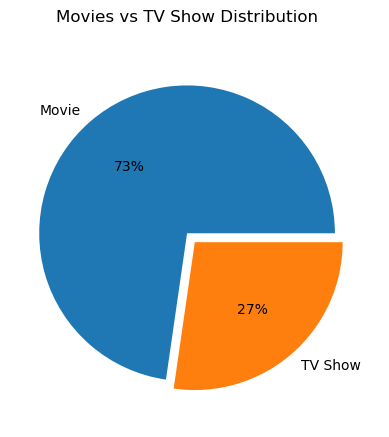

<Figure size 640x480 with 0 Axes>

In [239]:
labels = ['Movie','TV Show']
plt.pie(df_new.groupby('type')['type'].count(),labels = labels,explode = (0.08,0),autopct = '%0.0f%%')
plt.suptitle('Movies vs TV Show Distribution')
plt.show()
plt.savefig('1.png')

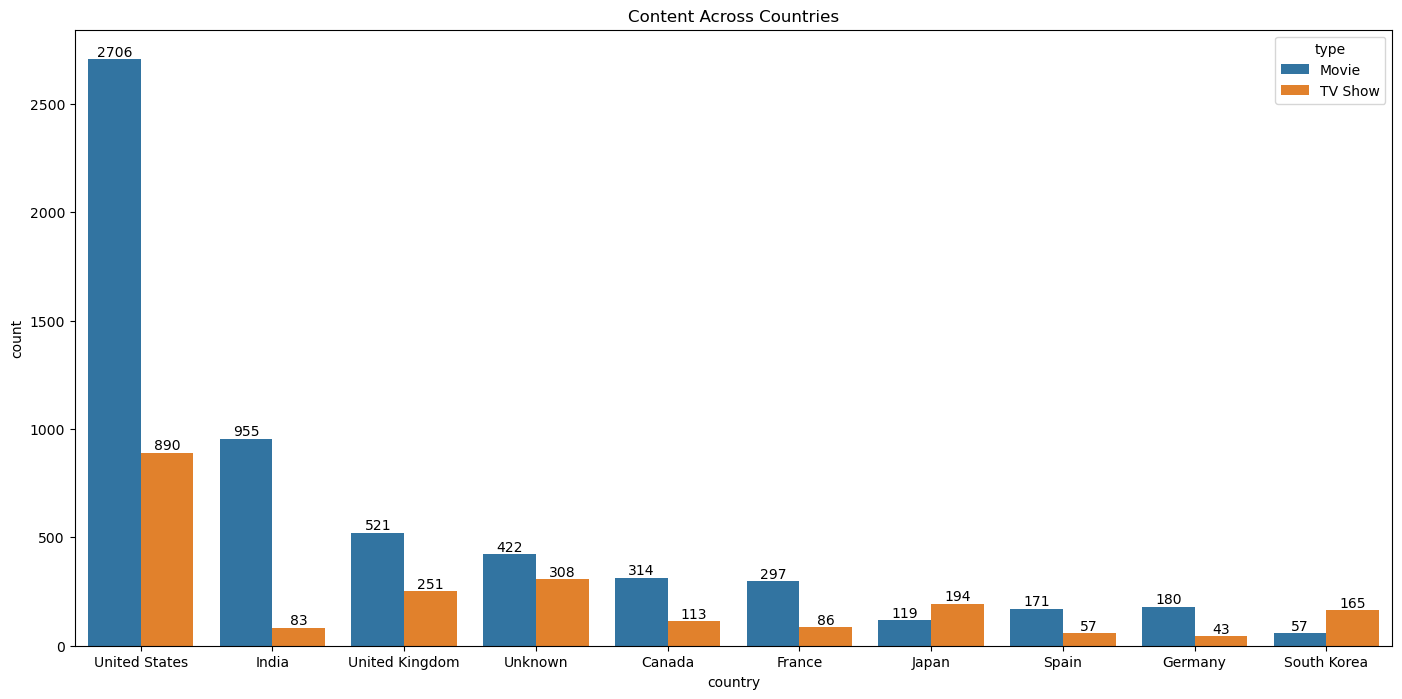

<Figure size 640x480 with 0 Axes>

In [240]:
df_temp = df_new.drop_duplicates(subset = ['country','title'])
x = df_temp['country'].value_counts().head(10)

plt.figure(figsize = (17,8))
plt.title('Content Across Countries')
label = sns.countplot(data = df_temp, x = 'country',hue = 'type',order = x.index)
for i in label.containers:
    label.bar_label(i)

plt.show()
plt.savefig('2.jpg')

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\2221011072.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp,x = 'director',palette = 'husl',
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\2221011072.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_tvs_temp,x = 'director',palette = 'husl',


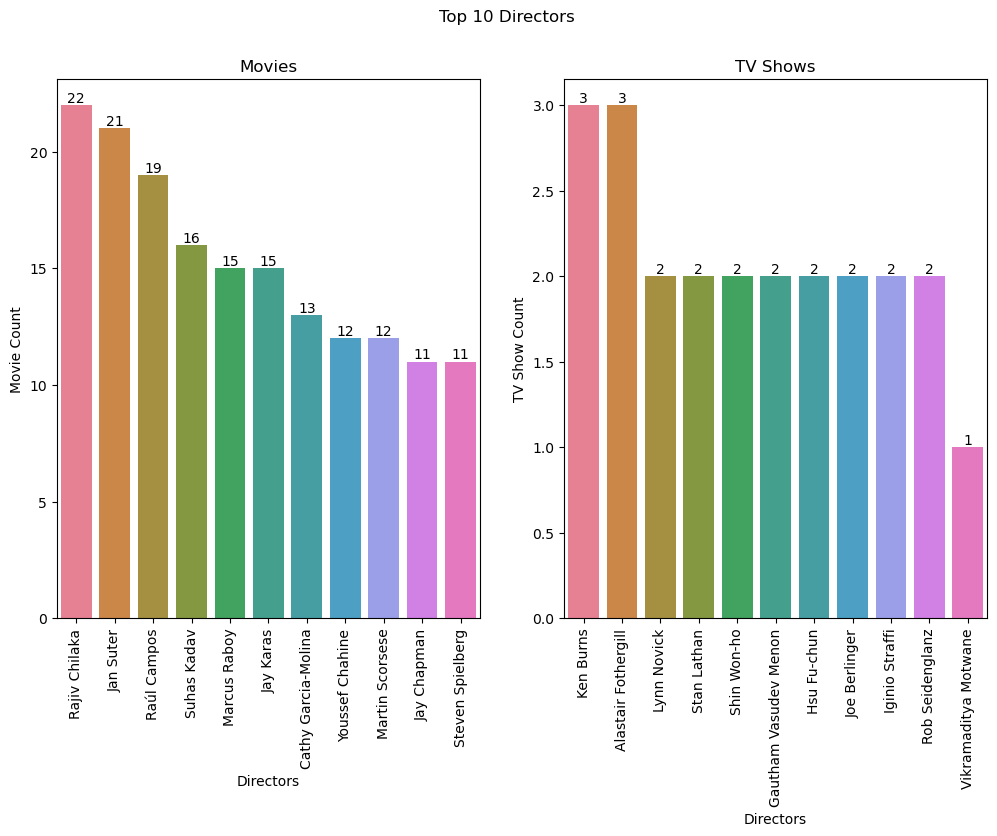

In [241]:
df_movies_temp = df_movies.drop_duplicates(subset = ['director','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['director','title'])

plt.figure(figsize = (12,7))
plt.suptitle('Top 10 Directors')

plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp,x = 'director',palette = 'husl',
                      order = df_movies_temp['director'].value_counts()[1:12].index)
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation = 90)
plt.xlabel('Directors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
label = sns.countplot(data = df_tvs_temp,x = 'director',palette = 'husl',
                      order = df_tvs_temp['director'].value_counts()[1:12].index)
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation = 90)
plt.xlabel('Directors')
plt.ylabel('TV Show Count')

plt.show()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\1256441405.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp,x = 'genre',palette = 'viridis',
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\1256441405.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_tvs_temp,x = 'genre',palette = 'viridis',


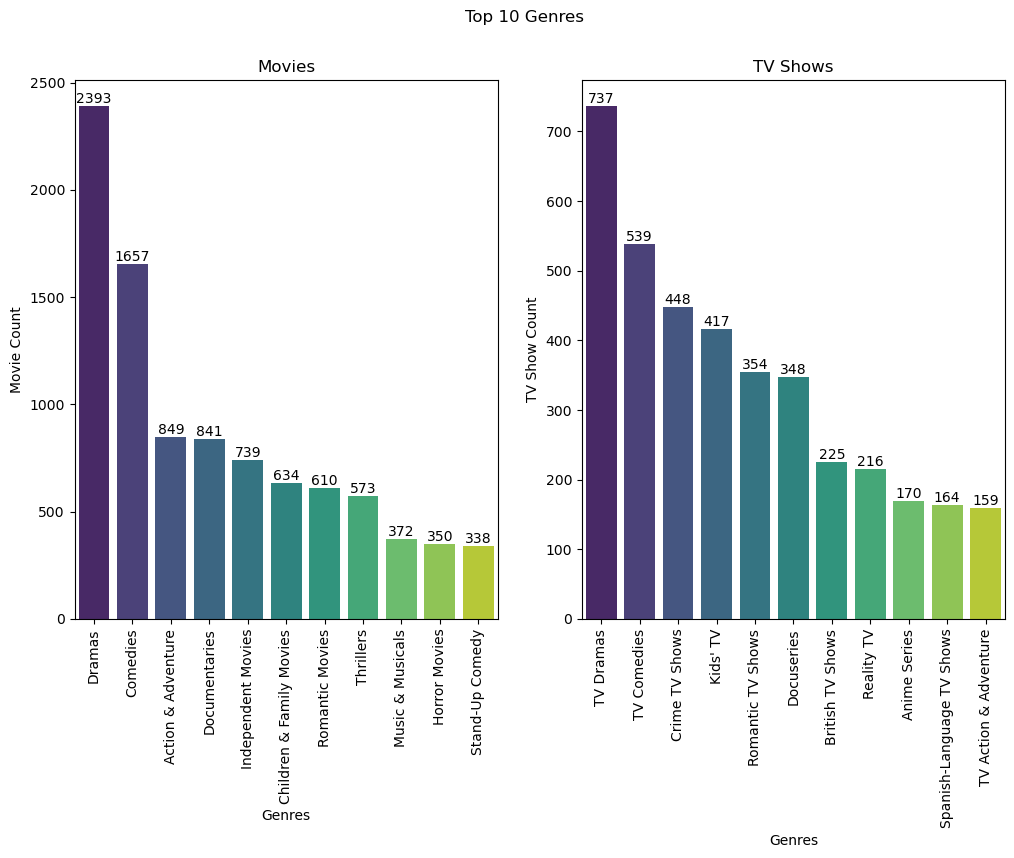

In [242]:
df_movies_temp = df_movies.drop_duplicates(subset = ['genre','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['genre','title'])

plt.figure(figsize = (12,7))
plt.suptitle('Top 10 Genres')

plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp,x = 'genre',palette = 'viridis',
                      order = df_movies_temp['genre'].value_counts()[1:12].index)
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation = 90)
plt.xlabel('Genres')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
label = sns.countplot(data = df_tvs_temp,x = 'genre',palette = 'viridis',
                      order = df_tvs_temp['genre'].value_counts()[1:12].index)
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation = 90)
plt.xlabel('Genres')
plt.ylabel('TV Show Count')

plt.show()

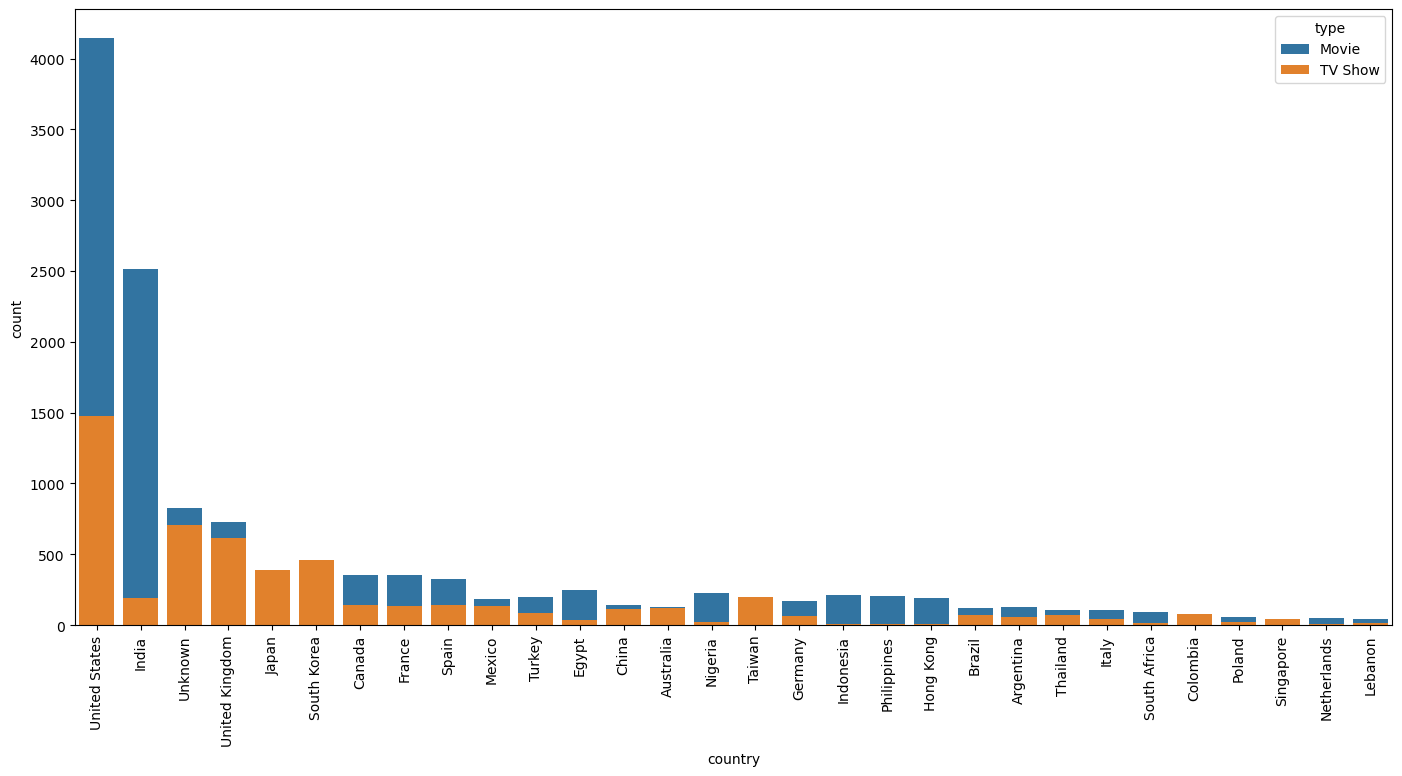

In [243]:
df_temp = df_new.drop_duplicates(subset = ['genre','title'])

plt.figure(figsize = (17,8))
plt.xticks(rotation = 90)
sns.countplot(data = df_temp, x = 'country', hue = 'type',dodge = False,
              order = df_temp['country'].value_counts().head(30).index)
plt.show()

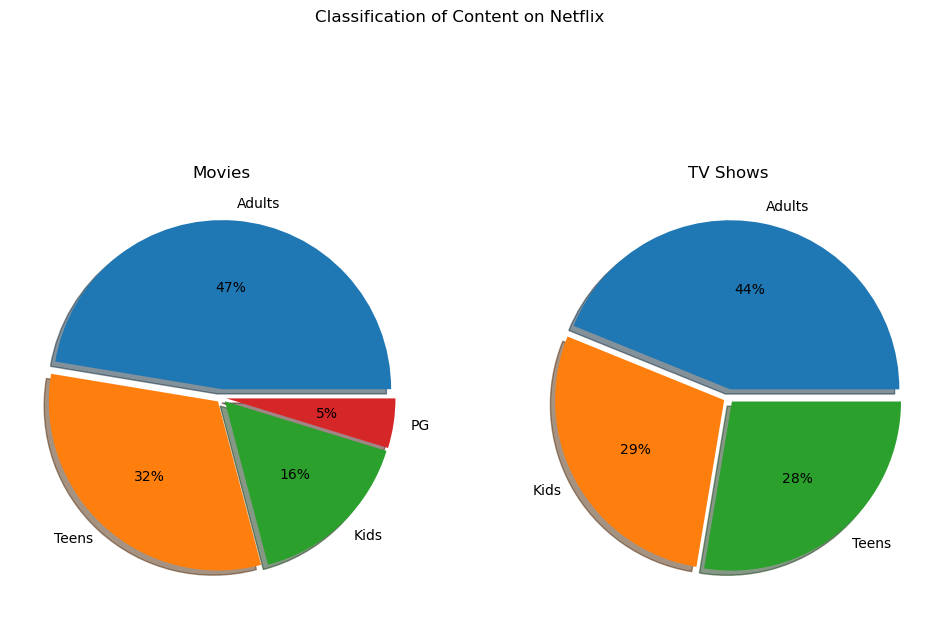

In [244]:
df_movies_temp = df_movies.drop_duplicates(subset = ['rating','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['rating','title'])

plt.figure(figsize = (12,8))
plt.suptitle('Classification of Content on Netflix')

plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(), labels = df_movies_temp['rating'].value_counts().index,
        autopct = '%.0f%%',explode = (0.05,0.03,0.03,0.03),shadow = True)
plt.title('Movies')

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(), labels = df_tvs_temp['rating'].value_counts().index,
        autopct = '%.0f%%',explode = (0.05,0.03,0.03),shadow = True)
plt.title('TV Shows')

plt.show()

In [245]:
df_tvs_temp['rating'].value_counts().index

Index(['Adults', 'Kids', 'Teens'], dtype='object', name='rating')

In [246]:
df_movies_temp['rating'].value_counts().index

Index(['Adults', 'Teens', 'Kids', 'PG'], dtype='object', name='rating')

In [247]:
df_movies_temp = df_movies.drop_duplicates(subset = ['year','title'])

mv_year = df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace = True)

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month = df_movies_temp['month_name'].value_counts().loc[month_order]

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day = df_movies_temp['weekdays'].value_counts().loc[day_order]

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\2700245922.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp,x = 'year',order = mv_year.index,palette = 'husl')
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\2700245922.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp,x = 'month_name',order = mv_month.index,palette = 'plasma')
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\2700245922.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countpl

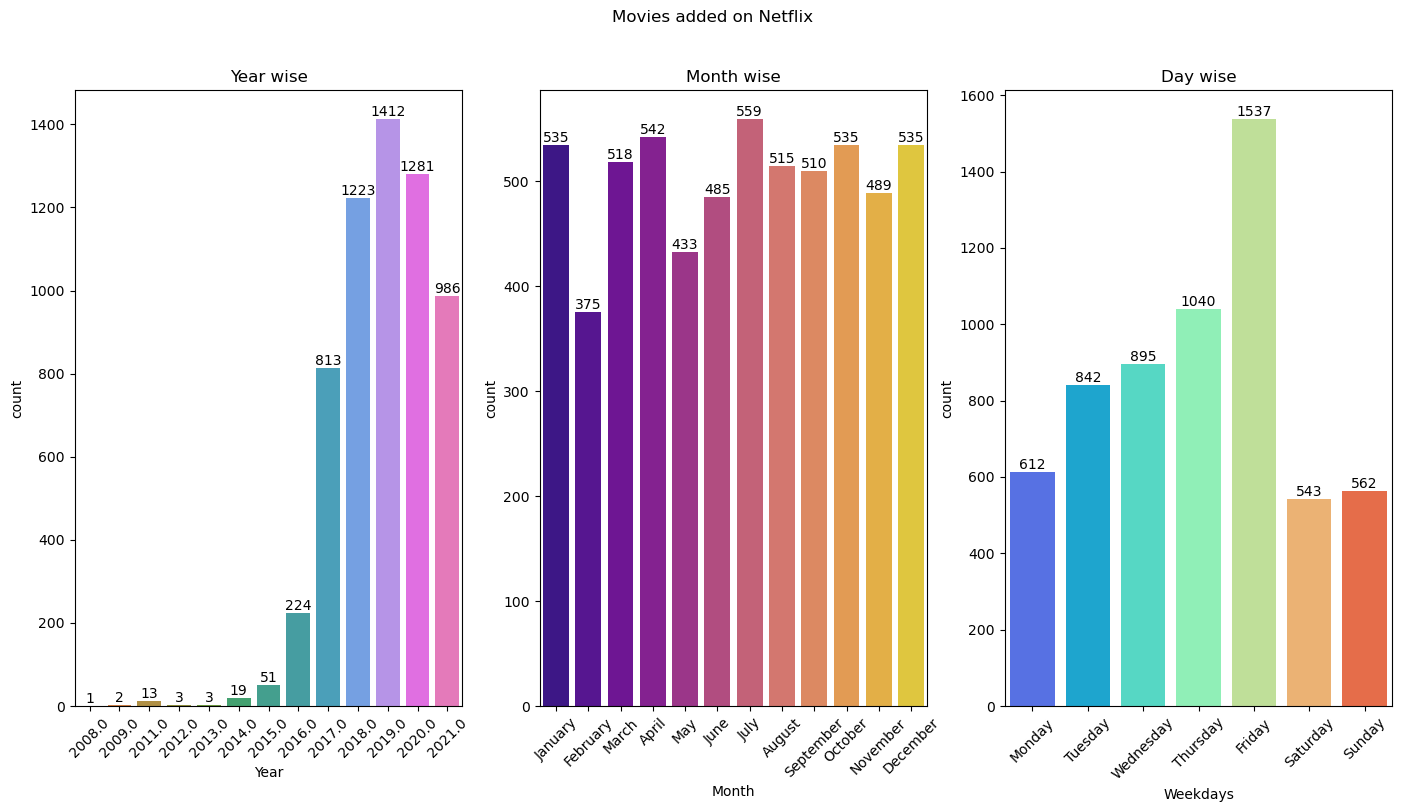

In [248]:
plt.figure(figsize = (17,8))
plt.suptitle('Movies added on Netflix')

plt.subplot(1,3,1)
label = sns.countplot(data = df_movies_temp,x = 'year',order = mv_year.index,palette = 'husl')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Year')
plt.title('Year wise')

plt.subplot(1,3,2)
label = sns.countplot(data = df_movies_temp,x = 'month_name',order = mv_month.index,palette = 'plasma')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Month')
plt.title('Month wise')

plt.subplot(1,3,3)
label = sns.countplot(data = df_movies_temp,x = 'weekdays',order = mv_day.index,palette = 'rainbow')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Weekdays')
plt.title('Day wise')

plt.show()

In [249]:
df_tvs_temp = df_tvs.drop_duplicates(subset = ['year','title'])

mv_year = df_tvs_temp['year'].value_counts()
mv_year.sort_index(inplace = True)

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month = df_tvs_temp['month_name'].value_counts().loc[month_order]

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day = df_tvs_temp['weekdays'].value_counts().loc[day_order]

In [250]:
df_movies_temp

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekdays,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25.0,9.0,2021.0,September,Saturday,United States,Kirsten Johnson,Unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,PG,91,Equestria's divided. But a bright-eyed hero be...,24.0,9.0,2021.0,September,Friday,Unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
177,Movie,Sankofa,2021-09-24,1993,Adults,125,"On a photo shoot in Ghana, an American model s...",24.0,9.0,2021.0,September,Friday,United States,Haile Gerima,Kofi Ghanaba,Dramas
329,Movie,The Starling,2021-09-24,2021,Teens,104,A woman adjusting to life after a loss contend...,24.0,9.0,2021.0,September,Friday,United States,Theodore Melfi,Melissa McCarthy,Comedies
426,Movie,Je Suis Karl,2021-09-23,2021,Adults,127,After most of her family is murdered in a terr...,23.0,9.0,2021.0,September,Thursday,Germany,Christian Schwochow,Luna Wedler,Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199828,Movie,Zinzana,2016-03-09,2015,Adults,96,Recovering alcoholic Talal wakes up inside a s...,9.0,3.0,2016.0,March,Wednesday,United Arab Emirates,Majid Al Ansari,Ali Suliman,Dramas
199864,Movie,Zodiac,2019-11-20,2007,Adults,158,"A political cartoonist, a crime reporter and a...",20.0,11.0,2019.0,November,Wednesday,United States,David Fincher,Mark Ruffalo,Cult Movies
199894,Movie,Zombieland,2019-11-01,2009,Adults,88,Looking to survive in a world taken over by zo...,1.0,11.0,2019.0,November,Friday,United States,Ruben Fleischer,Jesse Eisenberg,Comedies
199908,Movie,Zoom,2020-01-11,2006,PG,88,"Dragged from civilian life, a former superhero...",11.0,1.0,2020.0,January,Saturday,United States,Peter Hewitt,Tim Allen,Children & Family Movies


C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\986570420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_tvs_temp,x = 'year',order = mv_year.index,palette = 'plasma')
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\986570420.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_tvs_temp,x = 'month_name',order = mv_month.index,palette = 'rainbow')
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\986570420.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(dat

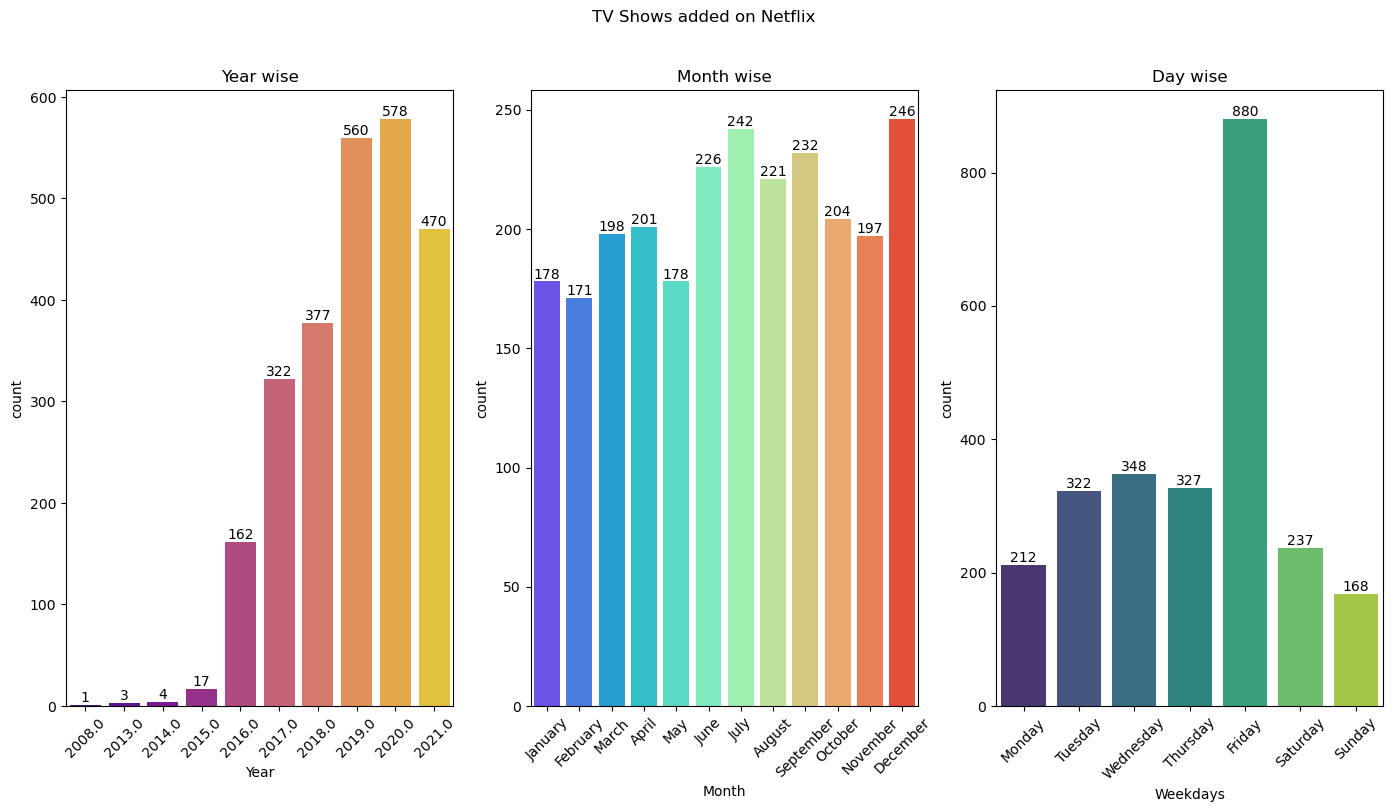

In [251]:
plt.figure(figsize = (17,8))
plt.suptitle('TV Shows added on Netflix')

plt.subplot(1,3,1)
label = sns.countplot(data = df_tvs_temp,x = 'year',order = mv_year.index,palette = 'plasma')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Year')
plt.title('Year wise')

plt.subplot(1,3,2)
label = sns.countplot(data = df_tvs_temp,x = 'month_name',order = mv_month.index,palette = 'rainbow')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Month')
plt.title('Month wise')

plt.subplot(1,3,3)
label = sns.countplot(data = df_tvs_temp,x = 'weekdays',order = mv_day.index,palette = 'viridis')
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation = 45)
plt.xlabel('Weekdays')
plt.title('Day wise')

plt.show()

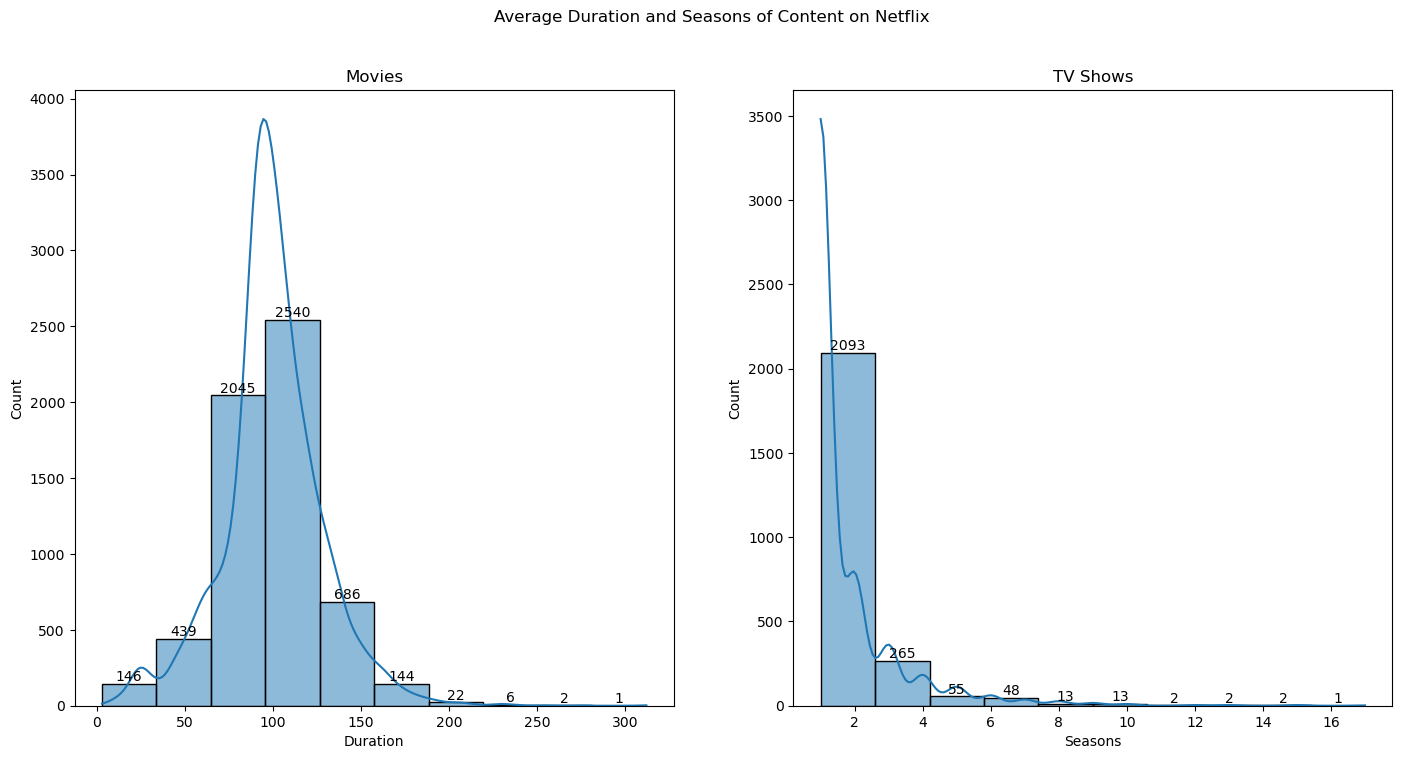

In [252]:
df_movies_temp = df_movies.drop_duplicates(subset = ['duration','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['Seasons','title'])

plt.figure(figsize = (17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
label = sns.histplot(df_movies_temp['duration'].astype(int),bins = 10,kde = True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Duration')
plt.title('Movies')

plt.subplot(1,2,2)
label = sns.histplot(df_tvs_temp['Seasons'].astype(int),bins = 10,kde = True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel('Seasons')
plt.title('TV Shows')

plt.show()

C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\889679509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies_temp['duration'] = df_movies_temp['duration'].astype(int)
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\889679509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs_temp['Seasons'] = df_tvs_temp['Seasons'].astype(int)


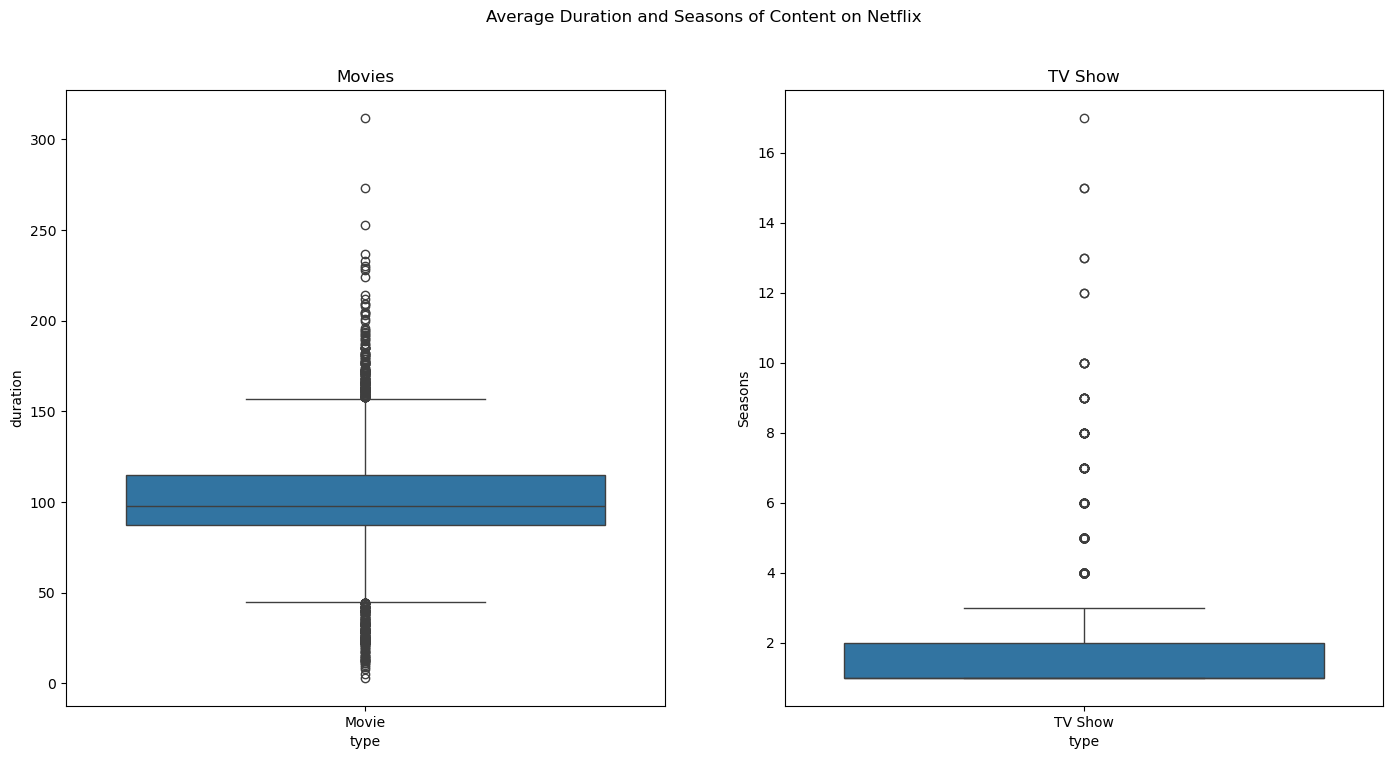

In [335]:
df_movies_temp['duration'] = df_movies_temp['duration'].astype(int)
df_tvs_temp['Seasons'] = df_tvs_temp['Seasons'].astype(int)

plt.figure(figsize = (17,8))
plt.suptitle('Average Duration and Seasons of Content on Netflix')

plt.subplot(1,2,1)
sns.boxplot(df_movies_temp, x = 'type', y = 'duration')
plt.title('Movies')

plt.subplot(1,2,2)
sns.boxplot(df_tvs_temp, x = 'type', y = 'Seasons')
plt.title('TV Show')

plt.show()

In [254]:
df_tvs_temp

,type,title,date_added,release_year,rating,Seasons,description,day,month,year,month_name,weekdays,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24.0,9.0,2021.0,September,Friday,South Africa,Unknown,Ama Qamata,International TV Shows
58,TV Show,Ganglands,2021-09-24,2021,Adults,1,To protect his family from a powerful drug lor...,24.0,9.0,2021.0,September,Friday,Unknown,Julien Leclercq,Sami Bouajila,Crime TV Shows
85,TV Show,Kota Factory,2021-09-24,2021,Adults,2,In a city of coaching centers known to train I...,24.0,9.0,2021.0,September,Friday,India,Unknown,Mayur More,International TV Shows
109,TV Show,Midnight Mass,2021-09-24,2021,Adults,1,The arrival of a charismatic young priest brin...,24.0,9.0,2021.0,September,Friday,Unknown,Mike Flanagan,Kate Siegel,TV Dramas
321,TV Show,The Great British Baking Show,2021-09-24,2021,Teens,9,A talented batch of amateur bakers face off in...,24.0,9.0,2021.0,September,Friday,United Kingdom,Andy Devonshire,Mel Giedroyc,British TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199413,TV Show,YOM,2018-06-07,2016,Kids,1,"With the mind of a human being, and the body o...",7.0,6.0,2018.0,June,Thursday,Unknown,Unknown,Sairaj,Kids' TV
199671,TV Show,Yu-Gi-Oh! Arc-V,2018-05-01,2015,Kids,2,Now that he's discovered the Pendulum Summonin...,1.0,5.0,2018.0,May,Tuesday,Japan,Unknown,Mike Liscio,Anime Series
199691,TV Show,Yunus Emre,2017-01-17,2016,Kids,2,"During the Mongol invasions, Yunus Emre leaves...",17.0,1.0,2017.0,January,Tuesday,Turkey,Unknown,Gökhan Atalay,International TV Shows
199727,TV Show,Zak Storm,2018-09-13,2016,Kids,3,Teen surfer Zak Storm is mysteriously transpor...,13.0,9.0,2018.0,September,Thursday,United States,Unknown,Michael Johnston,Kids' TV


C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\4057676933.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_movies_temp, x = 'cast',order = df_movies_temp['cast'].value_counts()[1:11].index,palette = 'husl')
C:\Users\govindmahotra\AppData\Local\Temp\ipykernel_19092\4057676933.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label = sns.countplot(data = df_tvs_temp, x = 'cast',order = df_tvs_temp['cast'].value_counts()[1:11].index,palette = 'rainbow')


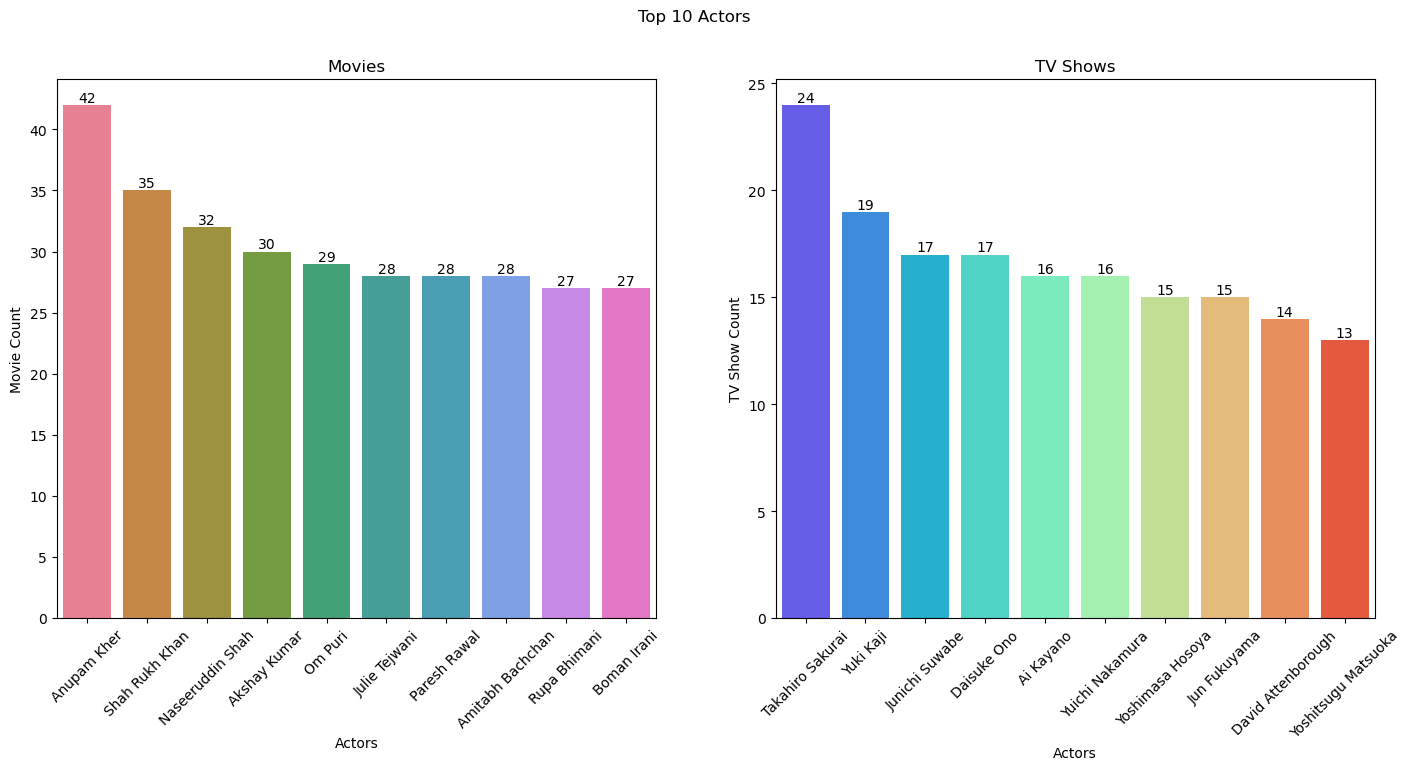

In [339]:
df_movies_temp = df_movies.drop_duplicates(subset = ['cast','title'])
df_tvs_temp = df_tvs.drop_duplicates(subset = ['cast','title'])

plt.figure(figsize = (17,7))
plt.suptitle('Top 10 Actors')

plt.subplot(1,2,1)
label = sns.countplot(data = df_movies_temp, x = 'cast',order = df_movies_temp['cast'].value_counts()[1:11].index,palette = 'husl')
for i in label.containers:
    label.bar_label(i)
plt.title('Movies')
plt.xticks(rotation = 45)
plt.xlabel('Actors')
plt.ylabel('Movie Count')

plt.subplot(1,2,2)
label = sns.countplot(data = df_tvs_temp, x = 'cast',order = df_tvs_temp['cast'].value_counts()[1:11].index,palette = 'rainbow')
for i in label.containers:
    label.bar_label(i)
plt.title('TV Shows')
plt.xticks(rotation = 45)
plt.xlabel('Actors')
plt.ylabel('TV Show Count')

plt.show()

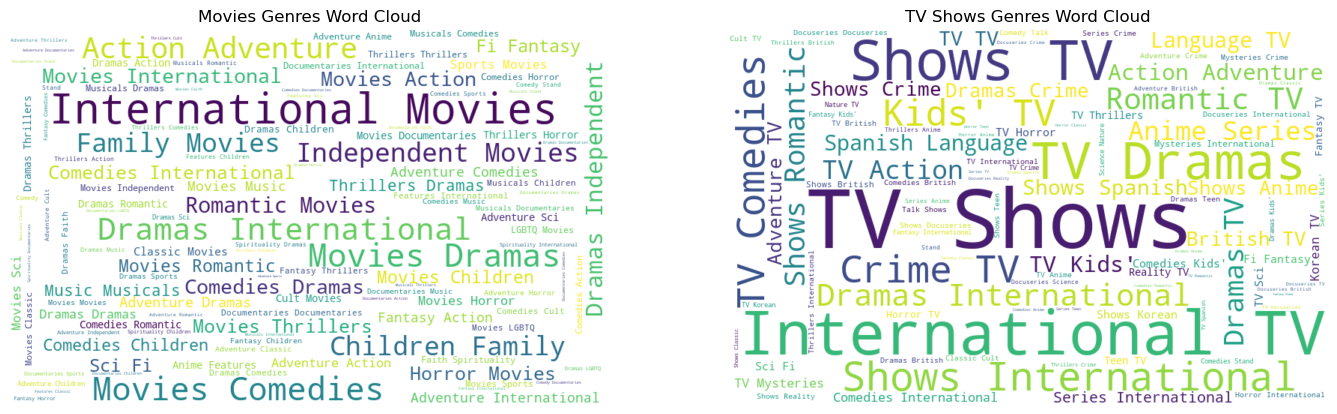

In [349]:
genre_text = " ".join(df_movies['genre'])
wordcloud = WordCloud(width = 800, height  = 500, background_color = 'white').generate(genre_text)

plt.figure(figsize = (17,10))

plt.subplot(1,2,1)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Movies Genres Word Cloud')

genre_text = " ".join(df_tvs['genre'])
wordcloud = WordCloud(width = 800, height  = 500, background_color = 'white').generate(genre_text)

plt.subplot(1,2,2)
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('TV Shows Genres Word Cloud')

plt.show()

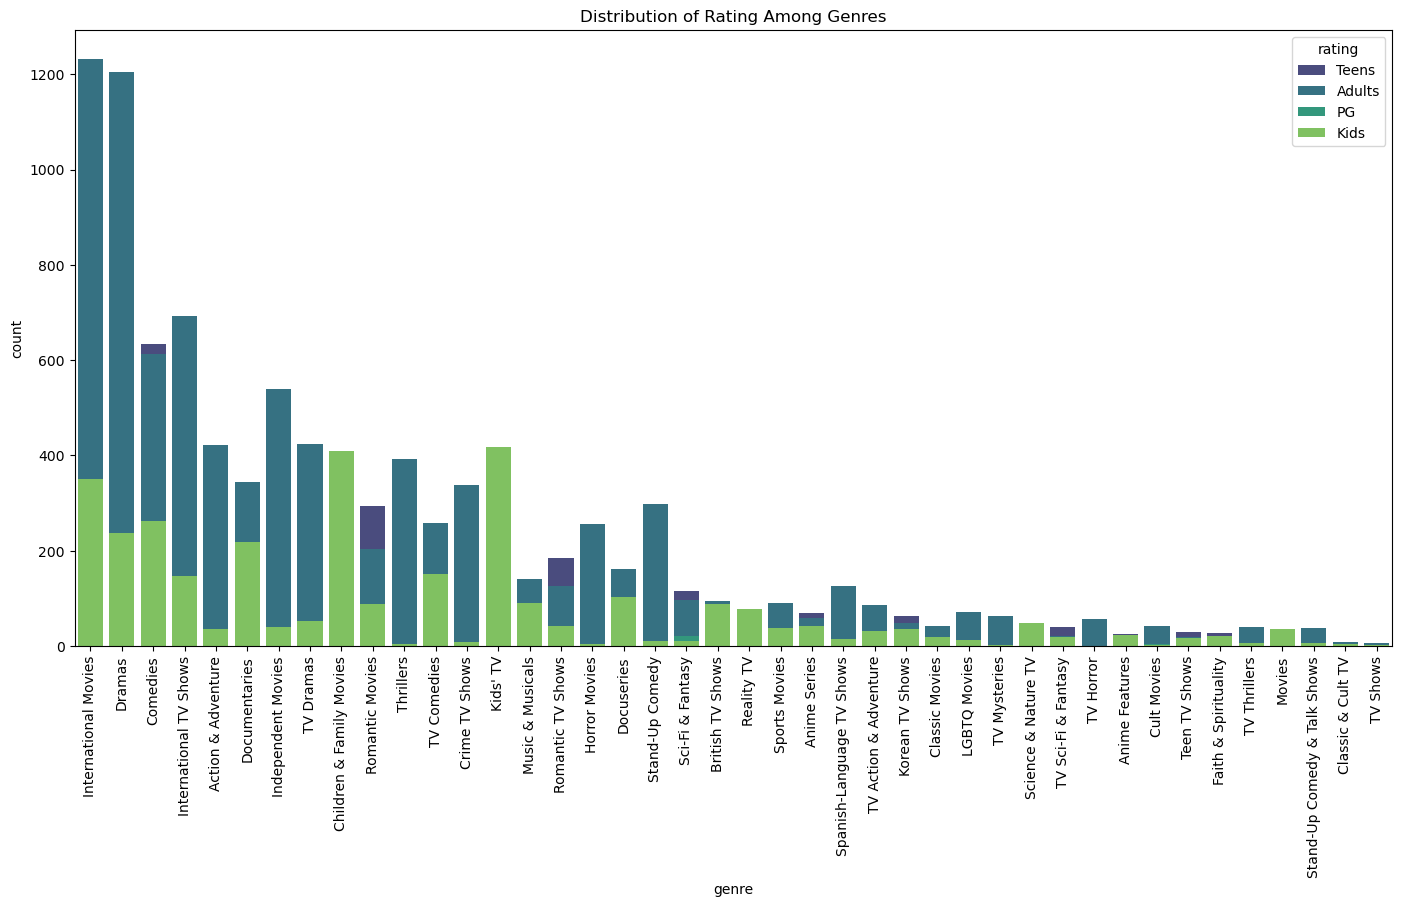

In [369]:
df_temp = df_new.drop_duplicates(subset = ['genre','title'])

plt.figure(figsize = (17,8))
plt.title('Distribution of Rating Among Genres')
sns.countplot(data = df_temp, x = 'genre', hue = 'rating', dodge = False,
              order = df_temp['genre'].value_counts().index, palette = 'viridis')
plt.xticks(rotation = 90)

plt.show()

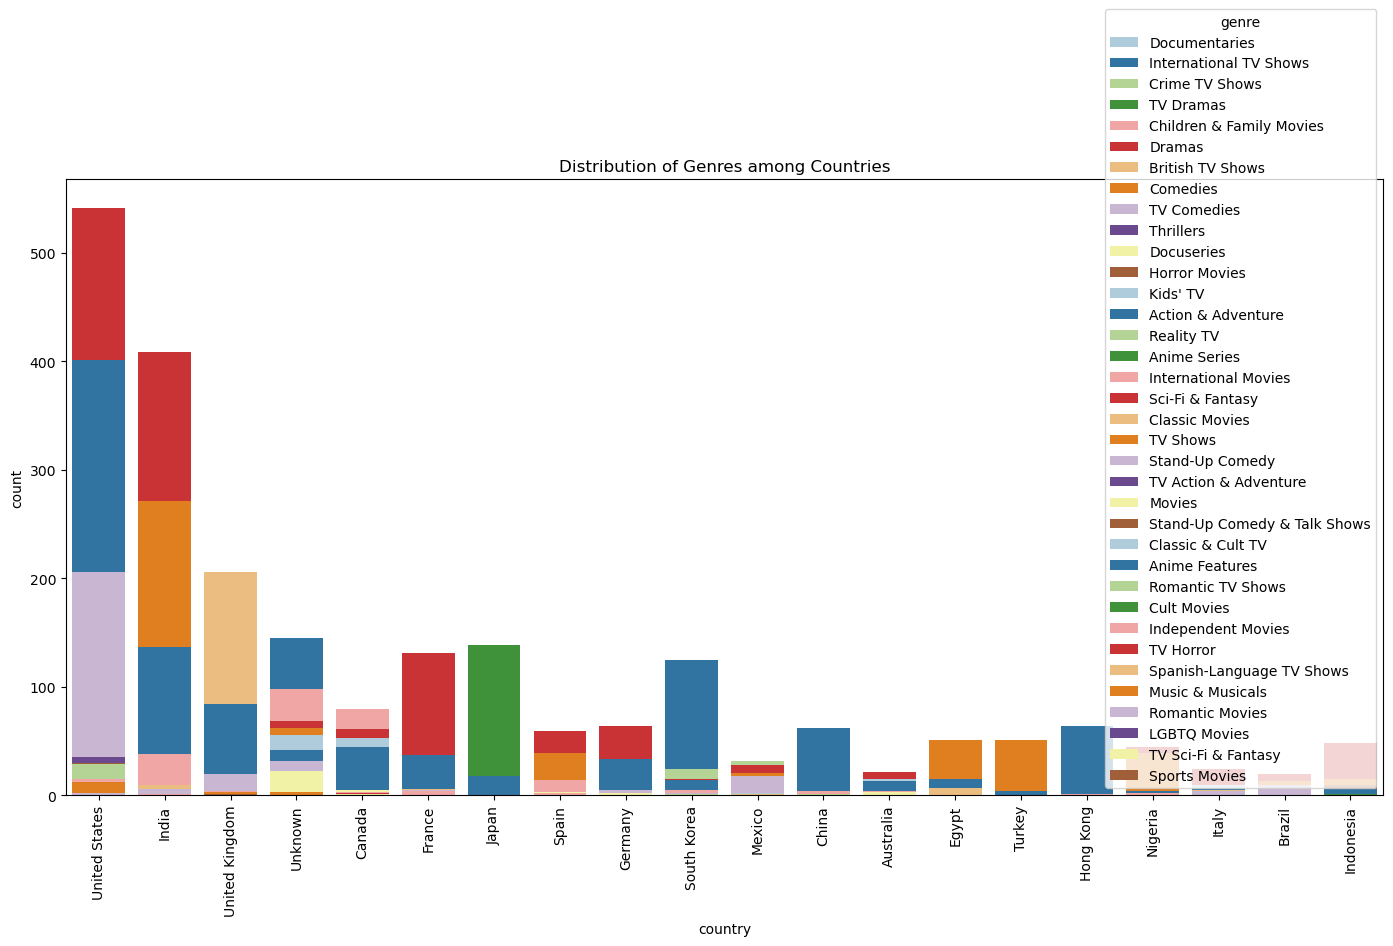

In [371]:
df_temp = df_new.drop_duplicates(subset = ['country','title'])

plt.figure(figsize = (17,8))
plt.title('Distribution of Genres among Countries')
sns.countplot(data = df_temp, x = 'country', hue = 'genre', dodge = False,
              order = df_temp['country'].value_counts().head(20).index, palette = 'Paired')
plt.xticks(rotation = 90)
plt.show()

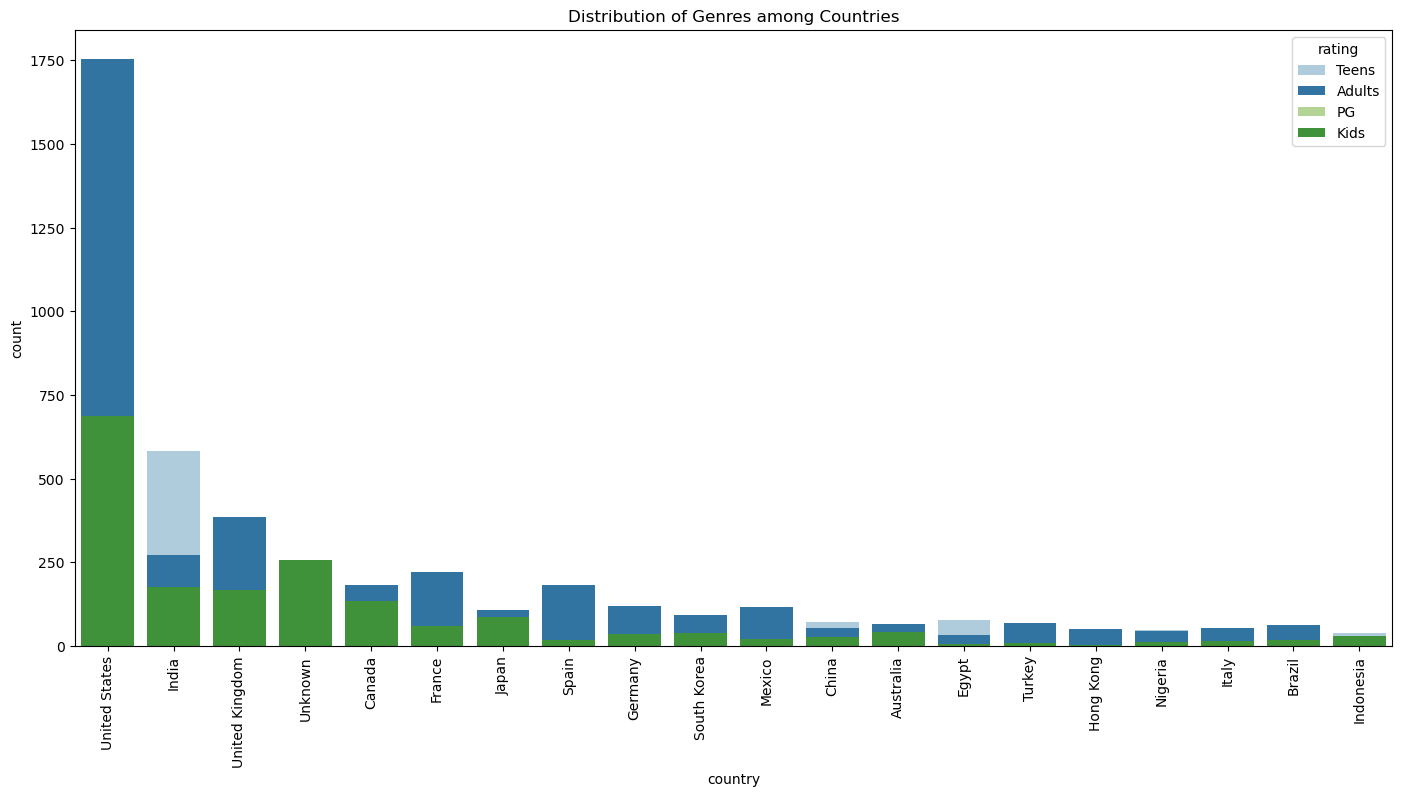

In [373]:
df_temp = df_new.drop_duplicates(subset = ['country','title'])

plt.figure(figsize = (17,8))
plt.title('Distribution of Genres among Countries')
sns.countplot(data = df_temp, x = 'country', hue = 'rating', dodge = False,
              order = df_temp['country'].value_counts().head(20).index, palette = 'Paired')
plt.xticks(rotation = 90)
plt.show()